## Setup

In [1]:
from pathlib import Path
import json
import sys
import tomllib

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

sys.path.append(str(Path.cwd().parent))
import cnp
import mfgp
import shells
from common import visualize

In [2]:
HOLDOUT_DIR = Path("../data/val_data")
MANIFEST = HOLDOUT_DIR / "validation_manifest.csv"

SHELL_CONFIG = Path("../configs/shell.toml")
CNP_CONFIG = Path("../configs/cnp.toml")
MFGP_CONFIG = Path("../configs/mfgp.toml")

CNP_MODEL = Path("../outputs/cnp/cnp_shell_v1_model.pth")
MFGP_MODEL = Path("../outputs/mfgp/mfgp_mfgp_v1_model.joblib")

OUTPUT_DIR = Path("../outputs/holdout")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CNP_HOLDOUT_CSV = OUTPUT_DIR / "cnp_holdout_predictions.csv"

## Load Configs

In [3]:
with open(CNP_CONFIG, "rb") as f:
    cnp_cfg = tomllib.load(f)
with open(MFGP_CONFIG, "rb") as f:
    mfgp_cfg = tomllib.load(f)

shell_config = shells.build_config(SHELL_CONFIG)
device = cnp_cfg["run"].get("device", "auto")
device = None if device == "auto" else device

mc_samples = int(cnp_cfg.get("prediction", {}).get("mc_samples", 30))
chunk_size = int(cnp_cfg.get("prediction", {}).get("chunk_size", 20000))
cnp_model, context_x, context_y, cnp_metadata = cnp.load_cnp_inference_checkpoint(
    CNP_MODEL,
    device=device,
)

dev = next(cnp_model.parameters()).device

print("CNP device:", dev)
print("Saved context:", len(context_x))
print("MF-GP shell n:", mfgp_cfg["shell"]["n_shell"])

CNP device: cpu
Saved context: 8192
MF-GP shell n: 20


/home/pknauss/xlzd/lib/python3.14/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Run CNP

In [4]:
manifest = pd.read_csv(MANIFEST)
required = {"filename", "R", "Z", "z_center", "fidelity"}
missing = required - set(manifest.columns)
if missing:
    raise ValueError(f"Manifest missing columns: {sorted(missing)}")

# Entire external dataset is HF
rows = []
for _, info in tqdm(manifest.iterrows(), total=len(manifest), desc="Holdout geometries"):
    path = HOLDOUT_DIR / info["filename"]

    R = float(info["R"])
    Z = float(info["Z"])
    z_center = float(info["z_center"])
    fidelity = float(info["fidelity"])
    
    # Load raw simulation
    events = shells.load_event_file(path)

    # Endpoint coordinates used to determine true shell
    events["r"] = np.hypot(events["x"], events["y"])
    events[shells.Z_FROM_CENTER_COLUMN] = np.abs(events["z"] - z_center)

    # Source-position features used by the CNP
    events["s_r"] = np.hypot(events["sx"], events["sy"])
    events["s_z_from_center"] = np.abs(events["sz"] - z_center)

    events["detector_R"] = R
    events["detector_Z"] = Z
    events["detector_z_center"] = z_center
    events["fidelity"] = fidelity
    events["source_file"] = path.name

    # Grab shell truths
    shell_cfg = shells.build_shell_config_for_manifest_row(
        pd.Series({
            "R": R,
            "Z": Z,
            "z_center": z_center,
        }),
        shell_config.shell,
    )

    shell_table = shells.build_shell_table(events, shell_cfg)
    labeled = shells.assign_shell_labels_for_file(
        events=events,
        shell_table_df=shell_table,
        phi_headers=shells.PHI_HEADERS,
    )
    if labeled.empty:
        print(f"[warn] no valid events in {path.name}")
        continue

    # Input to CNP
    x = labeled[
        [*shells.THETA_HEADERS, *shells.PHI_HEADERS]
    ].to_numpy(dtype=np.float32)

    truth = labeled[shells.TARGET_COLUMN].to_numpy(dtype=np.int64)

    n_events = len(labeled)
    n_shells = shell_config.shell.n_shells

    # Accumulate instead of storing N_events x N_shells for entire file
    prob_sum = np.zeros(n_shells, dtype=np.float64)
    std_sq_sum = np.zeros(n_shells, dtype=np.float64)
    truth_counts = np.zeros(n_shells, dtype=np.int64)

    # CNP Predict
    for start in range(0, n_events, chunk_size):
        end = min(start + chunk_size, n_events)
        target_x = torch.as_tensor(
            x[start:end],
            dtype=torch.float32,
            device=dev,
        )
        truth_chunk = truth[start:end]
        with torch.no_grad():
            mean, std = cnp_model.predict_proba_mc(
                context_x,
                context_y,
                target_x,
                mc_samples=mc_samples,
            )
        probs = mean.cpu().numpy()
        stds = std.cpu().numpy()
        prob_sum += probs.sum(axis=0)
        std_sq_sum += np.square(stds).sum(axis=0)
        truth_counts += np.bincount(truth_chunk, minlength=n_shells)

    # Put it all together
    y_cnp = prob_sum / n_events
    y_cnp_err = np.sqrt(std_sq_sum / n_events)
    y_raw = truth_counts / n_events
    for shell_i in range(n_shells):
        rows.append({
            "iteration": 0,
            "fidelity": fidelity,
            "n_samples": n_events,
            "detector_R": R,
            "detector_Z": Z,
            "detector_z_center": z_center,
            "shell_index": shell_i + 1,
            "y_cnp": y_cnp[shell_i],
            "y_cnp_err": y_cnp_err[shell_i],
            "y_raw": y_raw[shell_i],
            "source_file": path.name,
        })

Holdout geometries:   0%|          | 0/15 [00:00<?, ?it/s]

[warn] Some shell classes have low support, but they are kept for categorical CE because class IDs must remain fixed


/tmp/ipykernel_163811/1970347243.py:72: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  target_x = torch.as_tensor(


[warn] Some shell classes have low support, but they are kept for categorical CE because class IDs must remain fixed
[warn] Some shell classes have low support, but they are kept for categorical CE because class IDs must remain fixed
[warn] Some shell classes have low support, but they are kept for categorical CE because class IDs must remain fixed
[warn] Some shell classes have low support, but they are kept for categorical CE because class IDs must remain fixed
[warn] Some shell classes have low support, but they are kept for categorical CE because class IDs must remain fixed
[warn] Some shell classes have low support, but they are kept for categorical CE because class IDs must remain fixed


In [5]:
# Combine same detector sizes and save CNP output
cnp_holdout = pd.DataFrame(rows)
group_cols = [
    "iteration",
    "fidelity",
    "detector_R",
    "detector_Z",
    "shell_index",
]
cnp_holdout["_y_cnp_sum"] = cnp_holdout["y_cnp"] * cnp_holdout["n_samples"]
cnp_holdout["_y_raw_sum"] = cnp_holdout["y_raw"] * cnp_holdout["n_samples"]
cnp_holdout["_err_sq_sum"] = np.square(cnp_holdout["y_cnp_err"]) * cnp_holdout["n_samples"]
cnp_holdout = (
    cnp_holdout.groupby(group_cols, as_index=False)
    .agg(
        n_samples=("n_samples", "sum"),
        y_cnp_sum=("_y_cnp_sum", "sum"),
        y_raw_sum=("_y_raw_sum", "sum"),
        err_sq_sum=("_err_sq_sum", "sum"),
        source_file=("source_file", lambda x: ";".join(sorted(set(x)))),
    )
)
cnp_holdout["y_cnp"] = cnp_holdout["y_cnp_sum"] / cnp_holdout["n_samples"]
cnp_holdout["y_raw"] = cnp_holdout["y_raw_sum"] / cnp_holdout["n_samples"]
cnp_holdout["y_cnp_err"] = np.sqrt(
    cnp_holdout["err_sq_sum"] / cnp_holdout["n_samples"]
)
cnp_holdout = cnp_holdout[
    [
        "iteration",
        "fidelity",
        "n_samples",
        "detector_R",
        "detector_Z",
        "shell_index",
        "y_cnp",
        "y_cnp_err",
        "y_raw",
        "source_file",
    ]
]
cnp_holdout.to_csv(CNP_HOLDOUT_CSV, index=False)

print("Saved:", CNP_HOLDOUT_CSV)
print("Geometries:", cnp_holdout[["detector_R", "detector_Z"]].drop_duplicates().shape[0])
cnp_holdout.head()

Saved: ../outputs/holdout/cnp_holdout_predictions.csv
Geometries: 15


,iteration,fidelity,n_samples,detector_R,detector_Z,shell_index,y_cnp,y_cnp_err,y_raw,source_file
0,0,1.0,168362,279.0,578.0,1,0.001736,0.000865,0.001378,R279_H578_F1_2447keVgamma_withcuts.csv
1,0,1.0,168362,279.0,578.0,2,0.001674,0.000839,0.001622,R279_H578_F1_2447keVgamma_withcuts.csv
2,0,1.0,168362,279.0,578.0,3,0.001764,0.000744,0.001550,R279_H578_F1_2447keVgamma_withcuts.csv
3,0,1.0,168362,279.0,578.0,4,0.001921,0.000759,0.001752,R279_H578_F1_2447keVgamma_withcuts.csv
4,0,1.0,168362,279.0,578.0,5,0.001772,0.000631,0.001829,R279_H578_F1_2447keVgamma_withcuts.csv


## CNP Metrics and Plots

Predicted minus truth total: -0.23
    detector_R  detector_Z  distribution_mae  distribution_rmse
0        279.0       578.0          0.000468           0.000846
1        350.0      1400.0          0.000703           0.001212
2        400.0       200.0          0.000465           0.000732
3        524.0       221.0          0.000459           0.000803
4        638.0      1967.0          0.000664           0.001220
5        857.0      1767.0          0.000816           0.001849
6        925.0       867.0          0.000837           0.002285
7       1060.0      1056.0          0.000793           0.002108
8       1187.0       733.0          0.000724           0.001856
9       1246.0      1381.0          0.000690           0.002181
10      1500.0       250.0          0.000711           0.001250
11      1581.0      1626.0          0.000810           0.002713
12      1686.0      1232.0          0.000805           0.002421
13      1712.0       825.0          0.000630           0.001707
14   

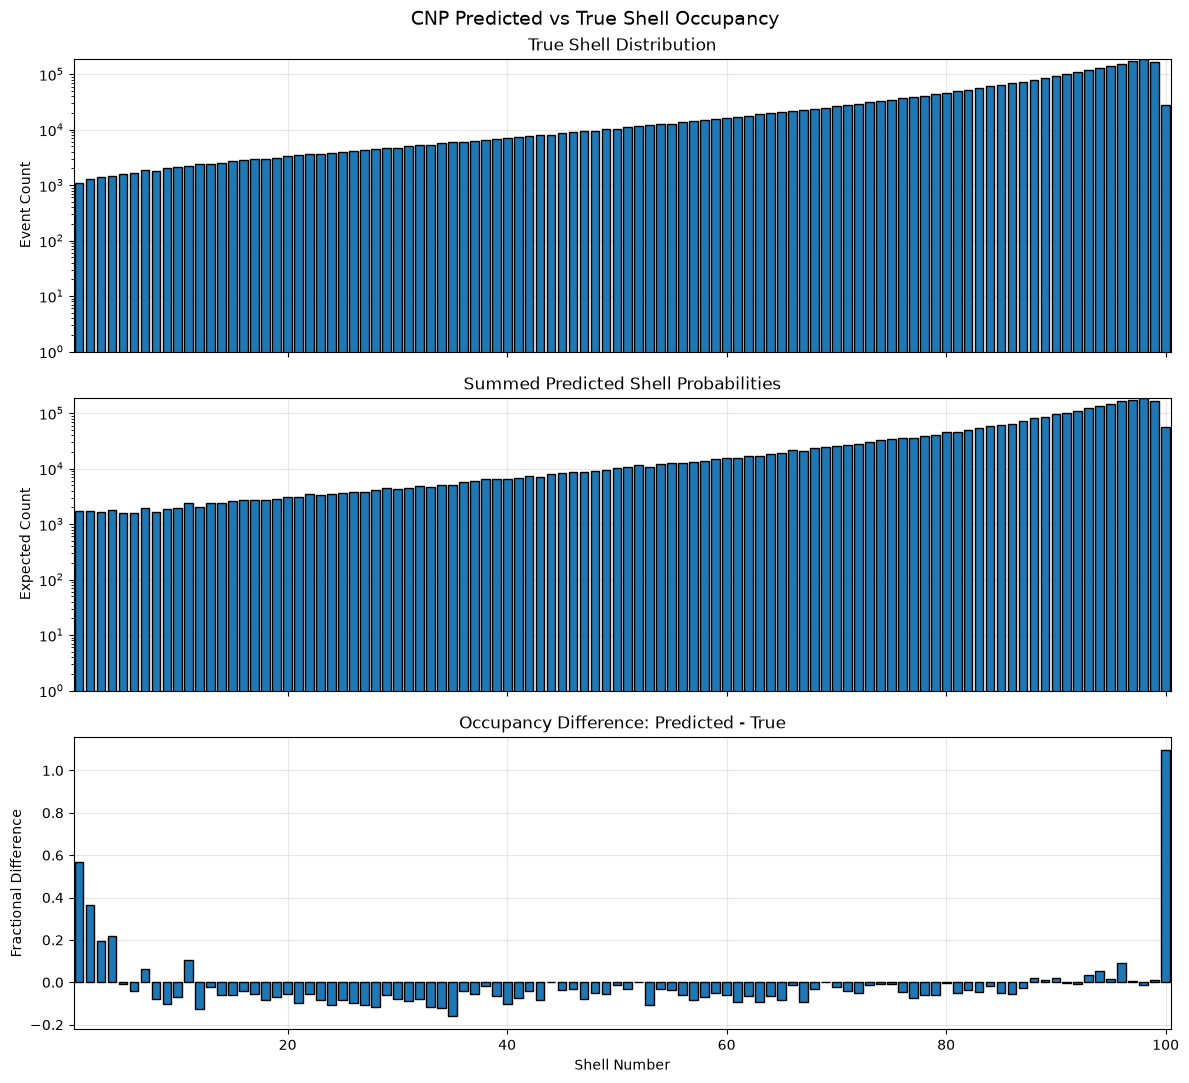

In [6]:
fig, axes = visualize.plot_cnp_pred_shell_occupancy(
    CNP_HOLDOUT_CSV
)
cnp_geom_metrics = (
    cnp_holdout.assign(
        abs_error=lambda df: np.abs(df["y_cnp"] - df["y_raw"]),
        sq_error=lambda df: np.square(df["y_cnp"] - df["y_raw"]),
    )
    .groupby(["detector_R", "detector_Z"])
    .agg(
        distribution_mae=("abs_error", "mean"),
        distribution_rmse=("sq_error", lambda x: np.sqrt(x.mean())),
    )
    .reset_index()
)

print(cnp_geom_metrics)

## Run MFGP

In [7]:
mfgp_holdout_result = shells.run_shell_mfgp_prediction(
    CNP_HOLDOUT_CSV,
    MFGP_CONFIG,
    model_path=MFGP_MODEL,
)

MF-GP prediction:   0%|          | 0/1 [00:00<?, ?chunk/s]

## MFGP Metrics and Plots

,value
n_points,15.000000
rmse,0.002958
mae,0.001624
r2,0.980521
bias,0.000375
median_absolute_error,0.000479
max_absolute_error,0.009607
pearson_r,0.992034
mean_predicted_sigma,0.002158
median_predicted_sigma,0.001723


PosixPath('../outputs/holdout/holdout_validation_points.png')

PosixPath('../outputs/holdout/holdout_validation_parity.png')

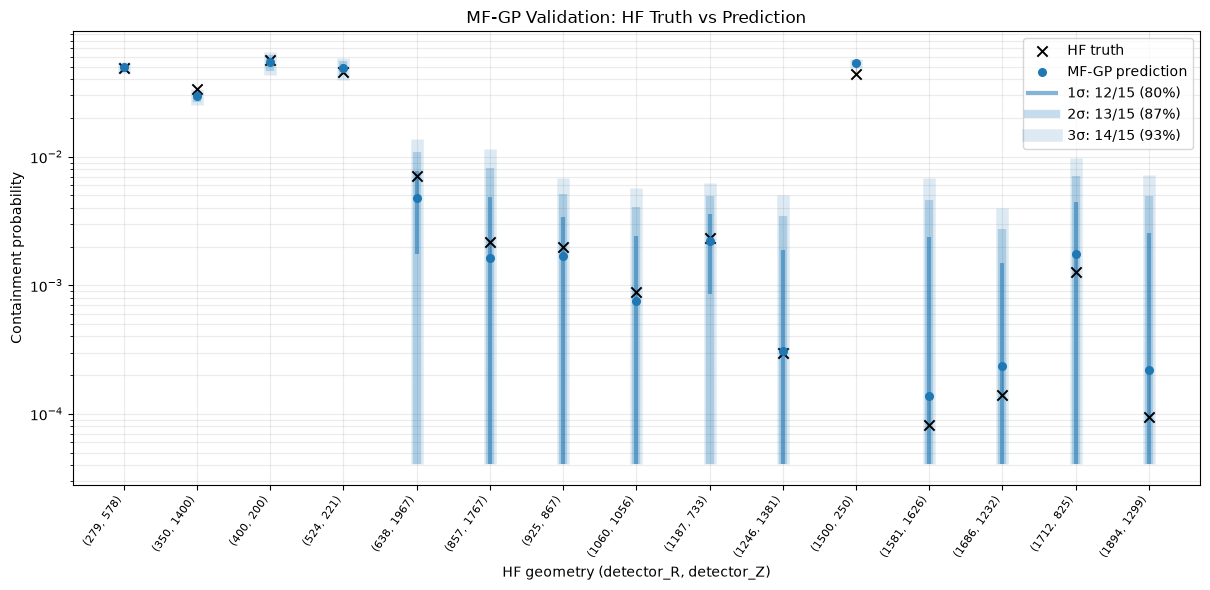

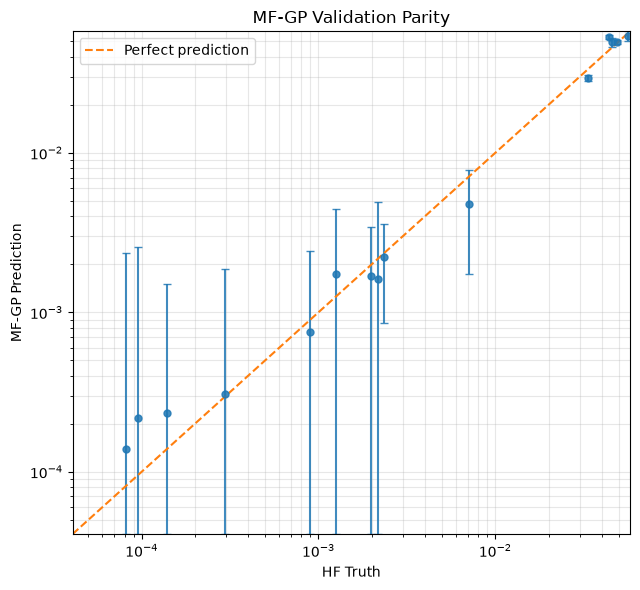

In [8]:
display(pd.Series(mfgp_holdout_result.metrics).to_frame("value"))

visualize.plot_mfgp_validation_points(
    mfgp_holdout_result,
    outpath = OUTPUT_DIR / "holdout_validation_points.png",
)
visualize.plot_mfgp_validation_parity(
    mfgp_holdout_result,
    outpath = OUTPUT_DIR / "holdout_validation_parity.png",
)
display(OUTPUT_DIR / "holdout_validation_points.png")
display(OUTPUT_DIR / "holdout_validation_parity.png")